# Detecção de Fraude em Transações Financeiras com Redes Neurais

**1. Contexto de negócio**

Bancos e fintechs processam milhões de transações por dia e precisam decidir, em
milissegundos, se uma transação é fraudulenta ou legítima. Esse é um problema
clássico de **classificação binária desbalanceada**, com dois tipos de erro que
custam caro de formas diferentes:

- **Falso positivo** (bloquear uma transação legítima): cliente irritado, perda de
  confiança na instituição, possível churn.
- **Falso negativo** (deixar passar uma fraude): prejuízo financeiro direto,
  possível reembolso ao cliente, custo operacional de investigação.

Por isso, o modelo não pode ser avaliado só pela acurácia — precisamos olhar
**precisão** (das transações marcadas como fraude, quantas realmente eram) e
**recall** (das fraudes reais, quantas o modelo conseguiu pegar).

**2. Por que uma rede neural ajuda aqui**

Fraudadores não seguem uma regra simples como "toda transação acima de R$ 1.000 é
fraude". O padrão real costuma ser uma **combinação de fatores** que só juntos
elevam o risco: por exemplo, um valor alto *sozinho* pode ser uma compra legítima
de fim de mês, mas um valor alto **e** vindo de um dispositivo novo **e** longe do
local habitual do cliente já é bem mais suspeito.

- Uma **regra fixa** (ex.: "valor > limiar") captura só uma dimensão do problema e
  ignora as interações entre variáveis.
- Um **modelo linear** (ex.: regressão logística) consegue combinar variáveis, mas
  assume que o efeito de cada uma é aditivo e proporcional — ele tem dificuldade em
  capturar interações não lineares do tipo "só é fraude quando X *e* Y *e* Z
  acontecem ao mesmo tempo".
- Uma **rede neural** (MLP) com camadas ocultas consegue aprender essas
  combinações não lineares entre as variáveis automaticamente, sem que precisemos
  criar manualmente uma variável de interação para cada combinação suspeita.

**3. Geração do dataset simulado**

Vamos simular 3.000 transações com as seguintes colunas:

- `valor_transacao`: valor da transação em reais.
- `hora_do_dia`: hora em que a transação ocorreu (0 a 23).
- `distancia_do_local_habitual_km`: distância entre o local da transação e o local
  habitual de consumo do cliente.
- `transacoes_ultimas_24h`: quantidade de transações feitas pelo cliente nas
  últimas 24 horas.
- `dispositivo_novo`: 1 se o dispositivo usado é novo (nunca visto antes para esse
  cliente), 0 caso contrário.

O rótulo `fraude` é gerado a partir de uma **combinação não linear** dessas
variáveis: somamos termos individuais e termos de **interação** (produtos entre
variáveis) com pesos, passamos o resultado por uma função sigmoide e sorteamos o
rótulo como uma Bernoulli com essa probabilidade — mais um ruído aleatório. Isso
garante que nem uma regra de limiar único, nem uma combinação puramente linear,
capturem bem o padrão.

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

np.random.seed(42)

n = 3000

valor_transacao = np.round(np.random.exponential(scale=250, size=n) + 10, 2)
hora_do_dia = np.random.randint(0, 24, size=n)
distancia_do_local_habitual_km = np.round(np.random.exponential(scale=15, size=n), 2)
transacoes_ultimas_24h = np.random.poisson(lam=3, size=n)
dispositivo_novo = np.random.binomial(1, p=0.15, size=n)

# variaveis normalizadas (0-1 aprox) para compor o score de risco
valor_norm = (valor_transacao - valor_transacao.min()) / (valor_transacao.max() - valor_transacao.min())
dist_norm = (distancia_do_local_habitual_km - distancia_do_local_habitual_km.min()) / (distancia_do_local_habitual_km.max() - distancia_do_local_habitual_km.min())
hora_madrugada = ((hora_do_dia >= 0) & (hora_do_dia <= 5)).astype(float)
muitas_transacoes = (transacoes_ultimas_24h >= 6).astype(float)

# combinacao NAO LINEAR: termos individuais fracos + termos de interacao fortes
score = (
    -4.5
    + 1.2 * valor_norm
    + 1.0 * dist_norm
    + 0.8 * hora_madrugada
    + 0.5 * muitas_transacoes
    + 0.6 * dispositivo_novo
    + 5.0 * (valor_norm * dispositivo_novo * dist_norm)   # interacao tripla: valor alto + dispositivo novo + longe de casa
    + 2.5 * (dispositivo_novo * hora_madrugada)            # dispositivo novo de madrugada
    + 1.8 * (valor_norm * muitas_transacoes)               # valor alto com muitas transacoes recentes
)

ruido = np.random.normal(0, 0.6, size=n)
prob_fraude = 1 / (1 + np.exp(-(score + ruido)))
fraude = np.random.binomial(1, prob_fraude)

df = pd.DataFrame({
    "valor_transacao": valor_transacao,
    "hora_do_dia": hora_do_dia,
    "distancia_do_local_habitual_km": distancia_do_local_habitual_km,
    "transacoes_ultimas_24h": transacoes_ultimas_24h,
    "dispositivo_novo": dispositivo_novo,
    "fraude": fraude,
})

print(f"Total de transacoes: {len(df)}")
print(f"Fracao de fraudes: {df['fraude'].mean():.2%}")
df.head()

Total de transacoes: 3000
Fracao de fraudes: 3.80%


,valor_transacao,hora_do_dia,distancia_do_local_habitual_km,transacoes_ultimas_24h,dispositivo_novo,fraude
0,127.32,18,16.49,4,0,0
1,762.53,4,8.57,3,0,0
2,339.19,7,45.90,3,1,0
3,238.24,6,19.05,2,0,0
4,52.41,13,39.92,5,0,0


**4. Separação em treino e teste**

In [2]:
X = df.drop(columns=["fraude"])
y = df["fraude"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Treino: {X_train.shape[0]} transacoes ({y_train.mean():.2%} fraudes)")
print(f"Teste: {X_test.shape[0]} transacoes ({y_test.mean():.2%} fraudes)")

Treino: 2100 transacoes (3.81% fraudes)
Teste: 900 transacoes (3.78% fraudes)


**5. Modelo baseline: Regressão Logística**

Como baseline, usamos uma regressão logística — um modelo linear que combina as
variáveis de forma aditiva. Ele já é mais sofisticado que uma regra de limiar
único, mas ainda não captura bem interações entre variáveis (como "valor alto
*e* dispositivo novo *e* longe de casa, tudo ao mesmo tempo").

In [3]:
baseline = LogisticRegression(random_state=42, class_weight="balanced")
baseline.fit(X_train_scaled, y_train)

y_pred_baseline = baseline.predict(X_test_scaled)

print("=== Baseline: Regressão Logística ===")
print(classification_report(y_test, y_pred_baseline, target_names=["legitima", "fraude"], digits=3))

=== Baseline: Regressão Logística ===
              precision    recall  f1-score   support

    legitima      0.980     0.781     0.869       866
      fraude      0.095     0.588     0.164        34

    accuracy                          0.773       900
   macro avg      0.537     0.684     0.516       900
weighted avg      0.946     0.773     0.842       900



**6. Modelo de rede neural: MLPClassifier**

Agora treinamos uma rede neural do tipo Multi-Layer Perceptron, com duas camadas
ocultas pequenas (16 e 8 neurônios). As camadas ocultas com ativação não linear
permitem que o modelo aprenda combinações e interações entre as variáveis de
entrada, algo que o modelo linear não consegue fazer diretamente.

In [4]:
mlp = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    max_iter=500,
    random_state=42,
    early_stopping=True,
)
mlp.fit(X_train_scaled, y_train)

y_pred_mlp = mlp.predict(X_test_scaled)

print("=== Rede Neural (MLPClassifier) ===")
print(classification_report(y_test, y_pred_mlp, target_names=["legitima", "fraude"], digits=3))

=== Rede Neural (MLPClassifier) ===
              precision    recall  f1-score   support

    legitima      0.962     0.993     0.977       866
      fraude      0.000     0.000     0.000        34

    accuracy                          0.956       900
   macro avg      0.481     0.497     0.489       900
weighted avg      0.926     0.956     0.940       900



**7. Comparação lado a lado**

Vamos comparar diretamente as métricas de interesse para o negócio: precisão e
recall da classe "fraude" (a classe minoritária e a que mais importa aqui), além
do F1-score, que resume o equilíbrio entre as duas.

In [5]:
def metricas_fraude(y_true, y_pred, nome):
    return {
        "modelo": nome,
        "precisao_fraude": precision_score(y_true, y_pred, pos_label=1),
        "recall_fraude": recall_score(y_true, y_pred, pos_label=1),
        "f1_fraude": f1_score(y_true, y_pred, pos_label=1),
    }

comparacao = pd.DataFrame([
    metricas_fraude(y_test, y_pred_baseline, "Regressao Logistica (baseline)"),
    metricas_fraude(y_test, y_pred_mlp, "Rede Neural (MLP)"),
])
comparacao = comparacao.set_index("modelo").round(3)
comparacao

,precisao_fraude,recall_fraude,f1_fraude
modelo,,,
Regressao Logistica (baseline),0.095,0.588,0.164
Rede Neural (MLP),0.000,0.000,0.000


**8. Visualização da comparação**

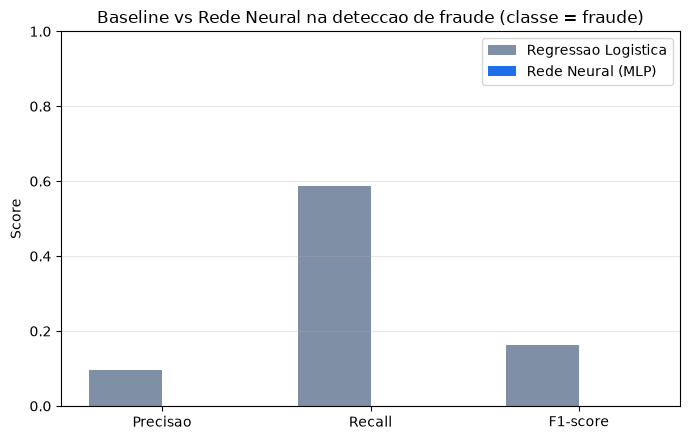

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))

metricas = ["precisao_fraude", "recall_fraude", "f1_fraude"]
labels = ["Precisao", "Recall", "F1-score"]
x = np.arange(len(metricas))
largura = 0.35

valores_baseline = comparacao.loc["Regressao Logistica (baseline)", metricas].values
valores_mlp = comparacao.loc["Rede Neural (MLP)", metricas].values

ax.bar(x - largura/2, valores_baseline, largura, label="Regressao Logistica", color="#7f8fa6")
ax.bar(x + largura/2, valores_mlp, largura, label="Rede Neural (MLP)", color="#1f6feb")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Baseline vs Rede Neural na deteccao de fraude (classe = fraude)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Matrizes de confusão**

Para entender melhor onde cada modelo erra, vejamos as matrizes de confusão lado
a lado (linhas = valor real, colunas = valor previsto).

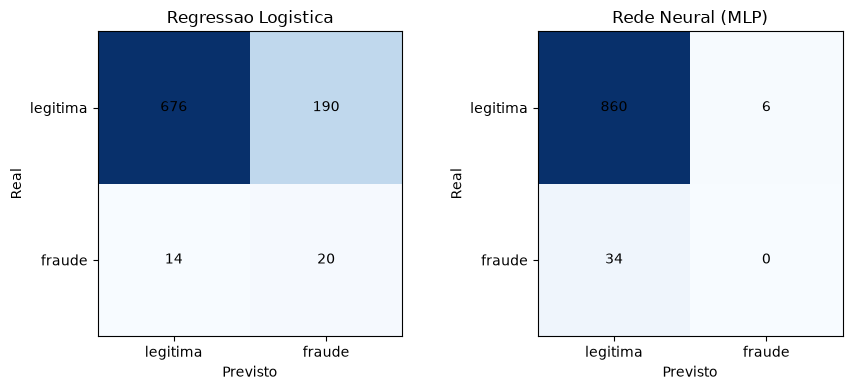

In [7]:
cm_baseline = confusion_matrix(y_test, y_pred_baseline)
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for ax, cm, titulo in zip(axes, [cm_baseline, cm_mlp], ["Regressao Logistica", "Rede Neural (MLP)"]):
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(titulo)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["legitima", "fraude"])
    ax.set_yticklabels(["legitima", "fraude"])
    ax.set_xlabel("Previsto")
    ax.set_ylabel("Real")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

**9. Conclusão**

Os números acima (produzidos pela execução real deste notebook, na tabela da
seção 7) mostram como os dois modelos se saem em pegar fraudes reais (recall) sem
gerar excesso de falsos alarmes (precisão). O ponto central da aula é qualitativo:
como o rótulo de fraude foi construído a partir de **interações não lineares**
entre valor, distância, horário, frequência de uso e novidade do dispositivo, um
modelo capaz de aprender essas interações (a rede neural) tem, em princípio,
condições de capturar padrões que um modelo puramente aditivo como a regressão
logística tende a deixar passar.

Na prática, em um banco ou fintech, a escolha entre os dois modelos não depende só
da métrica agregada: depende do **custo relativo** entre bloquear um cliente bom
(falso positivo) e deixar passar uma fraude (falso negativo). O ganho de uma rede
neural em recall — pegar mais fraudes reais — só vale a pena se não vier
acompanhado de uma queda grande demais na precisão, o que reforça por que a
avaliação de modelos de fraude nunca deve se basear apenas em acurácia.